# **BƯỚC 1: Kết nối Drive & Cấu hình thư viện**

In [10]:
from google.colab import drive
drive.mount('/content/drive')

import os
import cv2
import numpy as np
import shutil
import random
import joblib
import time
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# Đường dẫn dataset đã qua xử lý
drive_data_path = '/content/drive/MyDrive/Project_CV/Student-engagement-dataset-clean'
svm_save_path = '/content/drive/MyDrive/Project_CV/hog_svm_model.pkl'

print("Đã khởi tạo môi trường và thư viện thành công.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Đã khởi tạo môi trường và thư viện thành công.


# **BƯỚC 2: Phân chia tập dữ liệu (Train/Test)**

In [13]:
temp_dir = '/content/temp_data_hog'

if os.path.exists(temp_dir):
    shutil.rmtree(temp_dir)

print(f"Đang đọc dữ liệu từ: {drive_data_path}")

for subject in os.listdir(drive_data_path):
    subject_path = os.path.join(drive_data_path, subject)

    if not os.path.isdir(subject_path):
        continue

    for class_name in os.listdir(subject_path):
        class_path = os.path.join(subject_path, class_name)

        if not os.path.isdir(class_path):
            continue

        train_out = os.path.join(temp_dir, 'train', class_name)
        test_out  = os.path.join(temp_dir, 'test', class_name)

        os.makedirs(train_out, exist_ok=True)
        os.makedirs(test_out, exist_ok=True)

        images = [
            f for f in os.listdir(class_path)
            if f.lower().endswith(('.jpg', '.png', '.jpeg'))
        ]

        random.shuffle(images)
        split_idx = int(0.8 * len(images))

        for img in images[:split_idx]:
            shutil.copy(
                os.path.join(class_path, img),
                os.path.join(train_out, img)
            )

        for img in images[split_idx:]:
            shutil.copy(
                os.path.join(class_path, img),
                os.path.join(test_out, img)
            )

print("Hoàn tất chia dataset cho HOG + SVM")

Đang đọc dữ liệu từ: /content/drive/MyDrive/Project_CV/Student-engagement-dataset-clean
Hoàn tất chia dataset cho HOG + SVM


# **BƯỚC 3: Trích xuất đặc trưng HOG**

In [14]:
ORIENTATIONS = 9
PIXELS_PER_CELL = (8, 8)
CELLS_PER_BLOCK = (2, 2)

def extract_hog_features(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None

    features = hog(
        img,
        orientations=ORIENTATIONS,
        pixels_per_cell=PIXELS_PER_CELL,
        cells_per_block=CELLS_PER_BLOCK,
        block_norm='L2-Hys',
        transform_sqrt=True,
        visualize=False,
        feature_vector=True
    )

    return features

# **Load dataset + gán nhãn**

In [15]:
def load_dataset_hog(directory):
    features = []
    labels = []

    class_names = sorted(os.listdir(directory))
    class_map = {name: i for i, name in enumerate(class_names)}

    print(f"Đang xử lý: {directory}")

    for class_name in class_names:
        class_path = os.path.join(directory, class_name)
        files = os.listdir(class_path)

        for file in tqdm(files, desc=class_name, leave=False):
            feat = extract_hog_features(os.path.join(class_path, file))
            if feat is not None:
                features.append(feat)
                labels.append(class_map[class_name])

    return np.array(features), np.array(labels), class_names

print("Bắt đầu trích xuất HOG...")

X_train, y_train, class_names = load_dataset_hog(os.path.join(temp_dir, 'train'))
X_test,  y_test,  _           = load_dataset_hog(os.path.join(temp_dir, 'test'))

print("Hoàn tất trích xuất HOG")
print("Feature dim:", X_train.shape[1])
print("Train samples:", X_train.shape[0])
print("Test samples :", X_test.shape[0])


Bắt đầu trích xuất HOG...
Đang xử lý: /content/temp_data_hog/train


Looking Away:   0%|          | 0/338 [00:00<?, ?it/s]

bored:   0%|          | 0/286 [00:00<?, ?it/s]

confused:   0%|          | 0/295 [00:00<?, ?it/s]

drowsy:   0%|          | 0/210 [00:00<?, ?it/s]

...

confused:   0%|          | 0/74 [00:00<?, ?it/s]

drowsy:   0%|          | 0/53 [00:00<?, ?it/s]

engaged:   0%|          | 0/70 [00:00<?, ?it/s]

frustrated:   0%|          | 0/72 [00:00<?, ?it/s]

Hoàn tất trích xuất HOG
Feature dim: 8100
Train samples: 1694
Test samples : 426


# **BƯỚC 4: Huấn luyện SVM**

In [16]:
print("Huấn luyện SVM...")
start_time = time.time()

svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=42
)

svm_model.fit(X_train, y_train)

end_time = time.time()
print(f"Thời gian train: {end_time - start_time:.2f} giây")

joblib.dump(svm_model, svm_save_path)
print(f"Đã lưu model SVM: {svm_save_path}")

Huấn luyện SVM...
⏱Thời gian train: 16.98 giây
Đã lưu model SVM: /content/drive/MyDrive/Project_CV/hog_svm_model.pkl


# **BƯỚC 5: Đánh giá kết quả thực nghiệm**

KẾT QUẢ ĐÁNH GIÁ: HOG + SVM
Accuracy: 95.54%


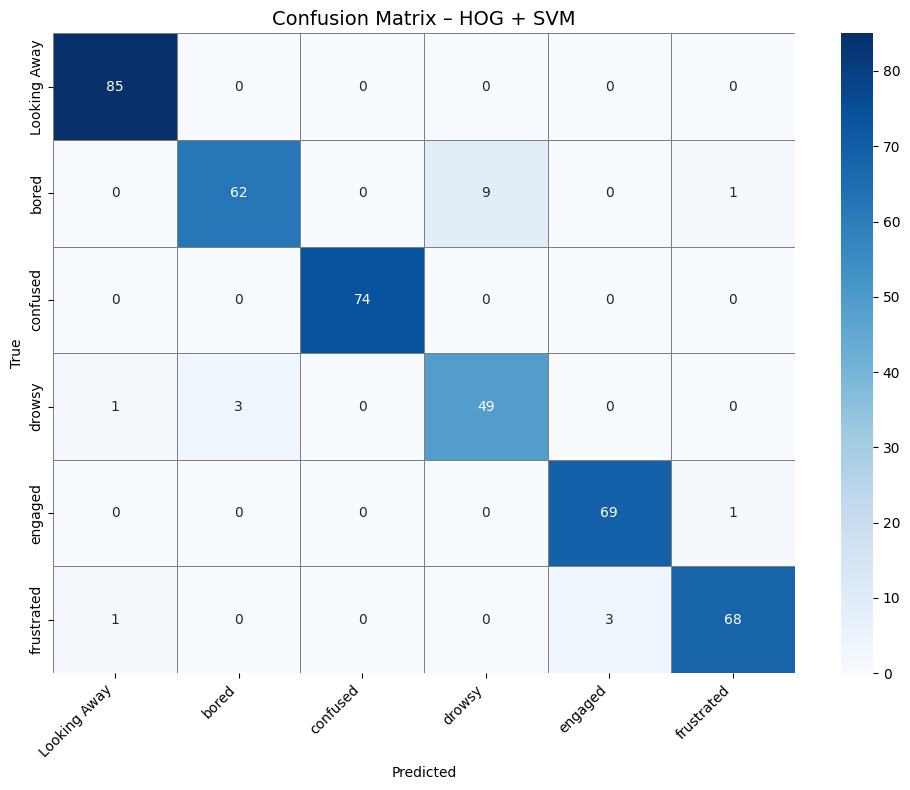

In [18]:
y_pred = svm_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("KẾT QUẢ ĐÁNH GIÁ: HOG + SVM")
print(f"Accuracy: {acc*100:.2f}%")

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    linecolor='gray'
)

plt.title("Confusion Matrix – HOG + SVM", fontsize=14)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()